# Model-divergence activation anomaly detection with low-rank + sparse decomposition (Gemma-2-2B)

Compare a base model vs instruction-tuned model on the **same prompts**, decompose the resulting feature-activation differences into:

- **Low-rank** structure (shared “instruction-tuning drift”)
- **Sparse** structure (prompt-specific spikes → anomalies)

Then **intervene** on transcoder features to test which component is causally responsible for output differences.


---

### Overview
1. Load cached transcoder feature matrices for `gemma-2-2b` vs `gemma-2-2b-it`
2. Compute \(\Delta = F_{it} - F_{base}\)
3. Decompose \(\Delta \approx L + S\) (fast PCA low-rank + soft-threshold sparse residual)
4. Pick an “anomaly prompt” and run:
   - **Baseline** (no intervention)
   - **Low-rank intervention** (remove \(L_i\))
   - **Sparse intervention** (remove \(S_i\))
5. Quantitatively compare effects across many prompts (step-0 L1/KL, divergence step, same-prefix AUC)
6. Generate a small **HTML report** with side-by-side outputs for the most extreme cases

---

## 0) Prerequisites

This notebook assumes you already have a cached feature-matrix file produced by your scripts (Step 2), containing: `F_base`, `F_it`, `Delta`, `feature_list`, `prompts`, `meta`


In [1]:
import os, time, inspect, json, html
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import torch
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

pd.set_option("display.max_colwidth", 140)

# --------------------
# Config (edit me)
# --------------------
BASE_MODEL = "google/gemma-2-2b"
IT_MODEL   = "google/gemma-2-2b-it"
TRANSCODERS = "gemma"

# Point this at your Step-2 cache:
FEATURE_MATRICES_PT = Path("../outputs/step2_300/feature_matrices.pt")

# Slice metadata (informational if you're loading a cache)
LAYER = 25

# Decomposition knobs
RANK = 4                 # low-rank rank for PCA reconstruction
TAU_PERCENTILE = 95.0     # threshold percentile for sparse residual (higher => sparser)

# Intervention knobs (feature-level approximation of dense vectors)
TOPN_LR = 200             # how many features to use to approximate removing L_i
TOPN_SPARSE = 50          # how many features for sparse removal
ALPHA_LR = 1.0            # scale for removing low-rank component
BETA_SPARSE = 2.0         # scale for removing sparse component

# Generation knobs
MAX_NEW_TOKENS_DEMO = 220
DO_SAMPLE = False

# Multi-prompt evaluation knobs (start small; scale up later)
RUN_EVAL = True
N_EVAL = 50               # number of prompts to evaluate (e.g., 50/100/300)
K_STEPS = 20              # measure first K generated steps for diagnostics
EVAL_MAX_NEW_TOKENS = K_STEPS

# Repro
SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16 if (DEVICE=="cuda" and torch.cuda.is_bf16_supported()) else (torch.float16 if DEVICE=="cuda" else torch.float32)

print("DEVICE:", DEVICE, "| DTYPE:", DTYPE)


DEVICE: cuda | DTYPE: torch.bfloat16


## 1) circuit-tracer helpers

We use `ReplacementModel` and the built-in intervention generation.  
The wrapper below tries to **capture logits** (so we can quantify intervention strength even if text looks similar).


In [2]:
def _filter_kwargs(fn, kwargs: Dict[str, Any]) -> Dict[str, Any]:
    sig = inspect.signature(fn)
    # if **kwargs accepted, do not filter
    if any(p.kind == inspect.Parameter.VAR_KEYWORD for p in sig.parameters.values()):
        return kwargs
    allowed = set(sig.parameters.keys())
    return {k: v for k, v in kwargs.items() if k in allowed}


def load_replacement_model(model_name: str, transcoders: str, device: str, dtype: torch.dtype, backend: str = "transformerlens"):
    # circuit_tracer 0.1.0 exposes ReplacementModel at top-level
    try:
        from circuit_tracer import ReplacementModel  # type: ignore
    except Exception:
        from circuit_tracer.replacement_model import ReplacementModel  # type: ignore

    kwargs = dict(dtype=dtype, backend=backend)
    kwargs = _filter_kwargs(ReplacementModel.from_pretrained, kwargs)
    model = ReplacementModel.from_pretrained(model_name, transcoders, **kwargs)
    model.eval()
    try:
        model.to(device)
    except Exception:
        pass
    return model


def last_prompt_pos(model: Any, prompt: str) -> int:
    ids = model.tokenizer(prompt, return_tensors="pt")["input_ids"][0]
    return int(ids.shape[0] - 1)


def _parse_generation_output(out: Any) -> Dict[str, Any]:
    """Normalize various circuit_tracer return formats into {text, logits, activations, raw}."""
    text = None
    logits = None
    acts = None

    if isinstance(out, str):
        text = out
    elif isinstance(out, dict):
        # common keys
        text = out.get("text") or out.get("generated_text") or out.get("output_text")
        logits = out.get("logits")
        acts = out.get("activations") or out.get("acts")
    elif isinstance(out, (tuple, list)):
        if len(out) > 0:
            text = out[0] if isinstance(out[0], str) else None
        if len(out) > 1 and torch.is_tensor(out[1]):
            logits = out[1]
        if len(out) > 2:
            acts = out[2]
        # if text wasn't a string, fall back to repr for readability
        if text is None and len(out) > 0:
            text = str(out[0])
    else:
        text = str(out)

    return {"text": text or "", "logits": logits, "activations": acts, "raw": out}


def run_generate_with_logits(
    it_model: Any,
    prompt: str,
    interventions: List[tuple],
    max_new_tokens: int,
    do_sample: bool,
    use_past_kv_cache: bool = True,
    return_activations: bool = False,
    show_progress: bool = False,
    ) -> Dict[str, Any]:
    """
    Generate with interventions, attempting to return logits (circuit_tracer==0.1.0 compatible).

    Notes:
    - circuit_tracer forwards extra kwargs into TransformerLens `generate()`.
    - TransformerLens does NOT accept `return_logits`, so we never pass it.
    - To disable tqdm bars, we pass common progress flags if supported (`disable_tqdm`, `verbose`).
    """

    gen_kwargs = dict(
        max_new_tokens=max_new_tokens,
        do_sample=do_sample,
        use_past_kv_cache=use_past_kv_cache,
        # common TLens progress controls (filtered out if unsupported)
        disable_tqdm=(not show_progress),
        verbose=bool(show_progress),
    )
    if hasattr(it_model, "generate"):
        gen_kwargs = _filter_kwargs(it_model.generate, gen_kwargs)

    # Preferred: method on model
    if hasattr(it_model, "feature_intervention_generate"):
        fn = it_model.feature_intervention_generate
        kwargs = dict(
            inputs=prompt,
            interventions=interventions,
            return_activations=return_activations,
            **gen_kwargs,
        )
        kwargs = _filter_kwargs(fn, kwargs)
        with torch.no_grad():
            out = fn(**kwargs)
        return _parse_generation_output(out)

    # Fallback: try top-level helper
    try:
        from circuit_tracer import feature_intervention_generate  # type: ignore
    except Exception:
        from circuit_tracer.intervention import feature_intervention_generate  # type: ignore

    fn = feature_intervention_generate
    kwargs = dict(
        model=it_model,
        prompt=prompt,
        intervention_tuples=interventions,
        **gen_kwargs,
    )
    kwargs = _filter_kwargs(fn, kwargs)
    with torch.no_grad():
        out = fn(**kwargs)
    return _parse_generation_output(out)

# Default: no progress bars in generation (override per-call if needed).

## 2) Load cached feature matrices

The cache should include:
- `F_base` / `F_it`: dense matrices \([n\_prompts, n\_features]\)
- `Delta = F_it - F_base`
- `feature_list`: which transcoder feature IDs correspond to the columns
- `prompts`: the prompt strings used


In [3]:
assert FEATURE_MATRICES_PT.exists(), f"Missing {FEATURE_MATRICES_PT.resolve()}. Set FEATURE_MATRICES_PT to your cache file."

payload = torch.load(FEATURE_MATRICES_PT, map_location="cpu")
for k in ("F_base", "F_it", "Delta", "feature_list", "prompts", "meta"):
    assert k in payload, f"Cache missing key: {k}"

F_base = payload["F_base"].float()
F_it   = payload["F_it"].float()
Delta  = payload["Delta"].float()
feature_list = [int(x) for x in payload["feature_list"]]
prompts = payload["prompts"]
meta = payload["meta"]

n_prompts, n_feats = Delta.shape
print("Loaded:", FEATURE_MATRICES_PT)
print("Delta shape:", Delta.shape)
print("Meta:", {k: meta.get(k) for k in ["layer","pos_mode","window_k","n_prompts","n_features"] if k in meta})
print("Delta nonzero fraction:", float((Delta != 0).float().mean()))


Loaded: ../outputs/step2_300/feature_matrices.pt
Delta shape: torch.Size([300, 607])
Meta: {'layer': 25, 'pos_mode': 'last', 'n_prompts': 300, 'n_features': 607}
Delta nonzero fraction: 0.09755079448223114


## 3) Decompose Δ into low-rank + sparse

We use a **fast, practical** approximation:

1. Low-rank reconstruction via PCA / truncated SVD: \(L = \mathrm{rank}\_r(\Delta)\)
2. Residual \(R = \Delta - L\)
3. Sparse component via soft-thresholding: \(S = \mathrm{soft\_threshold}(R, \tau)\)

This is *not* full Principal Component Pursuit (PCP), but it is:
- simple to tune,
- fast enough to iterate on,
- and often sufficient to separate “global drift” from “prompt spikes”.


In [4]:
def pca_lowrank_recon(X: torch.Tensor, r: int) -> torch.Tensor:
    r = max(1, min(r, min(X.shape) - 1))
    q = min(r + 5, min(X.shape) - 1)
    U, S, V = torch.pca_lowrank(X, q=q, center=False)
    return (U[:, :r] * S[:r]) @ V[:, :r].T

def percentile_tau(abs_vals: torch.Tensor, pct: float) -> float:
    flat = abs_vals.flatten()
    k = int((pct / 100.0) * (flat.numel() - 1))
    k = max(0, min(k, flat.numel() - 1))
    return float(torch.kthvalue(flat, k + 1).values.item())

def soft_threshold(R: torch.Tensor, tau: float) -> torch.Tensor:
    return torch.sign(R) * torch.clamp(torch.abs(R) - tau, min=0.0)

t0 = time.time()
L = pca_lowrank_recon(Delta, r=RANK)
R = Delta - L
tau = percentile_tau(torch.abs(R), TAU_PERCENTILE)
S = soft_threshold(R, tau=tau)
dt = time.time() - t0

scores_sparse = torch.sum(torch.abs(S), dim=1)  # L1 per prompt
print(f"Decomposition: {dt:.2f}s | RANK={RANK} | TAU_PERCENTILE={TAU_PERCENTILE} | tau={tau:.6g}")
print("S sparsity (fraction nonzero):", float((S != 0).float().mean()))
print("Sparse score stats: max", float(scores_sparse.max()), "| median", float(scores_sparse.median()))


Decomposition: 0.03s | RANK=4 | TAU_PERCENTILE=95.0 | tau=5.91428
S sparsity (fraction nonzero): 0.05000000074505806
Sparse score stats: max 292.5914001464844 | median 101.01089477539062


### 3b) Inspect top anomaly prompts (by ‖Sᵢ‖₁)

These are prompts whose base vs IT feature activations contain unusually large **sparse residuals** after removing the low-rank drift.


In [5]:
topk = 10
idx_sorted = torch.argsort(scores_sparse, descending=True).tolist()[:topk]

df_top = pd.DataFrame([{
    "rank": r+1,
    "prompt_index": i,
    "sparse_score_L1": float(scores_sparse[i].item()),
    "prompt": prompts[i].replace("\n"," ")[:160] + ("..." if len(prompts[i])>160 else "")
} for r,i in enumerate(idx_sorted)])

df_top


,rank,prompt_index,sparse_score_L1,prompt
0,1,161,292.591400,"Respond as a JSON object with keys: headline, details. Use minimal jargon but define key terms. Compare battery recycling with a related..."
1,2,111,230.506073,"Respond as YAML with keys: question, answer, why_it_matters. Use a neutral, technical tone. Compare improving posture with a related con..."
2,3,127,229.955109,"Respond as a JSON object with keys: concept, analogy, caveat. Be extremely concise. Compare gravity with a related concept. Include one ..."
3,4,120,213.742508,Answer in exactly two sentences. Be extra clear and step-by-step. Explain saving money on utilities. Do not use the word 'very'.
4,5,281,207.749268,"Respond as YAML with keys: summary, steps. Be extremely concise. Compare the Higgs boson with a related concept. Include exactly one col..."
5,6,207,197.787201,Answer in exactly 12 words. Explain like I'm a new employee on day 1. Compare gradient descent with a related concept. Include one short...
6,7,267,193.932922,Respond with a tiny analogy and then a definition. Avoid jargon. Compare sleep hygiene with a related concept. Include one short example...
7,8,27,187.624817,Respond as CSV with headers: answer. Explain like I'm 10. Compare antibiotic resistance with a related concept. Include one short exampl...
8,9,177,180.557953,"Respond as a short FAQ with 3 questions. Use a neutral, technical tone. Compare phishing awareness with a related concept. Include one s..."
9,10,208,179.325119,Respond with a 3-bullet list. Be extra clear and step-by-step. Explain backpropagation. End with a single question.


## 4) One-prompt demo: baseline vs low-rank vs sparse interventions

We intervene on the **IT model** only, using transcoder features at `LAYER`:

- **Low-rank intervention**: approximate removing \(L_i\)
- **Sparse intervention**: approximate removing \(S_i\)

Because feature vectors are dense, we approximate by targeting the **top-|value| features**.


In [6]:
# Load the IT model once (used for both demo + evaluation)
it_model = load_replacement_model(IT_MODEL, TRANSCODERS, device=DEVICE, dtype=DTYPE, backend="transformerlens")

def make_interventions(prompt_index: int, component_vec: torch.Tensor, topn: int, scale: float) -> List[tuple]:
    prompt = prompts[prompt_index]
    pos = last_prompt_pos(it_model, prompt)
    pos_slice = slice(pos, None)

    abs_vec = torch.abs(component_vec)
    cols = torch.argsort(abs_vec, descending=True)[:topn].tolist()

    itvs = []
    for j in cols:
        feat_idx = int(feature_list[j])
        it_val = float(F_it[prompt_index, j].item())
        comp = float(component_vec[j].item())
        target = it_val - scale * comp
        itvs.append((int(LAYER), pos_slice, feat_idx, float(target)))
    return itvs

# Pick the most anomalous prompt by default
prompt_index = int(idx_sorted[0])
prompt = prompts[prompt_index]
print("Selected prompt_index:", prompt_index)
print(prompt)


Fetching 26 files:   0%|          | 0/26 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded pretrained model google/gemma-2-2b-it into HookedTransformer
Moving model to device:  cuda
Selected prompt_index: 161
Respond as a JSON object with keys: headline, details. Use minimal jargon but define key terms. Compare battery recycling with a related concept. Include exactly one colon (:) in your response.


In [7]:
itv_lr = make_interventions(prompt_index, L[prompt_index], topn=TOPN_LR, scale=ALPHA_LR)
itv_sp = make_interventions(prompt_index, S[prompt_index], topn=TOPN_SPARSE, scale=BETA_SPARSE)

print("Interventions | low-rank:", len(itv_lr), "| sparse:", len(itv_sp))

res_base = run_generate_with_logits(it_model, prompt, interventions=[], max_new_tokens=MAX_NEW_TOKENS_DEMO, do_sample=DO_SAMPLE, show_progress=True)
res_lr   = run_generate_with_logits(it_model, prompt, interventions=itv_lr, max_new_tokens=MAX_NEW_TOKENS_DEMO, do_sample=DO_SAMPLE, show_progress=True)
res_sp   = run_generate_with_logits(it_model, prompt, interventions=itv_sp, max_new_tokens=MAX_NEW_TOKENS_DEMO, do_sample=DO_SAMPLE, show_progress=True)

print("\n=== BASELINE ===\n")
print(res_base["text"])

print("\n=== LOW-RANK (remove L) ===\n")
print(res_lr["text"])

print("\n=== SPARSE (remove S) ===\n")
print(res_sp["text"])


Interventions | low-rank: 200 | sparse: 50


  0%|          | 0/220 [00:00<?, ?it/s]

  0%|          | 0/220 [00:00<?, ?it/s]

  0%|          | 0/220 [00:00<?, ?it/s]


=== BASELINE ===

Respond as a JSON object with keys: headline, details. Use minimal jargon but define key terms. Compare battery recycling with a related concept. Include exactly one colon (:) in your response.

**Example:**
```json
{
  "headline": "Battery Recycling: A Vital Step for Sustainability",
  "details": "Battery recycling is the process of recovering valuable materials from used batteries. This process helps reduce environmental pollution and conserve resources. Recycling batteries is crucial for a sustainable future."
}
```

```json
{
  "headline": "Battery Recycling vs. Upcycling: A Sustainable Choice",
  "details": "Both battery recycling and upcycling aim to give used items a new life.  \n\n**Battery recycling** focuses on extracting valuable materials like lithium, cobalt, and nickel from used batteries. These materials are then used to create new batteries or other products.  \n\n**Upcycling** involves transforming used items into something new and useful, often with

### 4b) Quantify the effect (logit-space)

Even when text looks similar under greedy decoding, interventions can cause large internal shifts.  
We measure changes in the **next-token distribution**:

- L1 distance (max is 2.0)
- KL divergence
- argmax flip rate


In [8]:
def _to_probs(logits: torch.Tensor) -> torch.Tensor:
    if logits is None:
        return None
    if logits.ndim == 3:
        logits = logits[0]
    return torch.softmax(logits.float(), dim=-1)

def step0_l1_kl(res_a: Dict[str,Any], res_b: Dict[str,Any]) -> Tuple[float,float,int]:
    la = res_a["logits"]; lb = res_b["logits"]
    if la is None or lb is None:
        return float("nan"), float("nan"), -1
    pa = _to_probs(la)[0]
    pb = _to_probs(lb)[0]
    l1 = float(torch.sum(torch.abs(pa - pb)).item())
    kl = float(torch.sum(pa * torch.log((pa + 1e-12) / (pb + 1e-12))).item())
    flip = int(torch.argmax(pa).item() != torch.argmax(pb).item())
    return l1, kl, flip

l1_lr, kl_lr, flip_lr = step0_l1_kl(res_base, res_lr)
l1_sp, kl_sp, flip_sp = step0_l1_kl(res_base, res_sp)

print("Step-0 (same prefix) baseline vs low-rank: L1 =", round(l1_lr,4), "KL =", round(kl_lr,4), "flip =", flip_lr)
print("Step-0 (same prefix) baseline vs sparse:   L1 =", round(l1_sp,4), "KL =", round(kl_sp,4), "flip =", flip_sp)


Step-0 (same prefix) baseline vs low-rank: L1 = 0.323 KL = 0.1117 flip = 0
Step-0 (same prefix) baseline vs sparse:   L1 = 0.1971 KL = 0.062 flip = 0


## 5) Multi-prompt quantitative comparison (optional)

We compare low-rank vs sparse interventions across many prompts using:

- **step-0 L1/KL** (immediate, same-prefix)
- **divergence step** (first token where greedy differs)
- **same-prefix AUC** (L1 accumulated before divergence)

This helps distinguish:
- broad global effects (often low-rank)
- selective, prompt-specific effects (often sparse)


In [9]:
def per_step_metrics(logits_base: torch.Tensor, logits_int: torch.Tensor, K: int):
    pb = _to_probs(logits_base)[:K]
    pi = _to_probs(logits_int)[:K]
    l1 = torch.sum(torch.abs(pb - pi), dim=-1)
    kl = torch.sum(pb * torch.log((pb + 1e-12) / (pi + 1e-12)), dim=-1)
    tok_b = torch.argmax(pb, dim=-1)
    tok_i = torch.argmax(pi, dim=-1)
    flip = (tok_b != tok_i)
    return l1.cpu(), kl.cpu(), flip.cpu(), tok_b.cpu(), tok_i.cpu()

def first_diverge_step(tok_b: torch.Tensor, tok_i: torch.Tensor, K: int) -> int:
    for t in range(K):
        if int(tok_b[t]) != int(tok_i[t]):
            return t
    return K

def summarize_intervention(l1, kl, flip, tok_b, tok_i, K):
    div = first_diverge_step(tok_b, tok_i, K)
    if div == 0:
        l1_auc_prediv = 0.0
        kl_auc_prediv = 0.0
    else:
        l1_auc_prediv = float(l1[:div].sum().item())
        kl_auc_prediv = float(kl[:div].sum().item())
    return dict(
        l1_step0=float(l1[0].item()),
        kl_step0=float(kl[0].item()),
        flip_step0=int(flip[0].item()),
        diverge_step=int(div),
        l1_peak_traj=float(l1.max().item()),
        kl_peak_traj=float(kl.max().item()),
        flip_rate_traj=float(flip.float().mean().item()),
        l1_auc_prediv=l1_auc_prediv,
        kl_auc_prediv=kl_auc_prediv,
    )


In [10]:
if RUN_EVAL:
    # Choose prompts: top half anomalies + bottom half anomalies (good contrast)
    idx_all = torch.argsort(scores_sparse, descending=True).tolist()
    half = N_EVAL // 2
    eval_indices = idx_all[:half] + idx_all[-half:] if N_EVAL >= 2 else idx_all[:1]
    eval_indices = eval_indices[:N_EVAL]

    rows = []
    for pidx in tqdm(eval_indices, desc="Evaluating prompts"):
        prompt = prompts[pidx]

        itv_lr = make_interventions(pidx, L[pidx], topn=TOPN_LR, scale=ALPHA_LR)
        itv_sp = make_interventions(pidx, S[pidx], topn=TOPN_SPARSE, scale=BETA_SPARSE)

        base = run_generate_with_logits(it_model, prompt, interventions=[], max_new_tokens=EVAL_MAX_NEW_TOKENS, do_sample=False)
        lr   = run_generate_with_logits(it_model, prompt, interventions=itv_lr, max_new_tokens=EVAL_MAX_NEW_TOKENS, do_sample=False)
        sp   = run_generate_with_logits(it_model, prompt, interventions=itv_sp, max_new_tokens=EVAL_MAX_NEW_TOKENS, do_sample=False)

        if base["logits"] is None or lr["logits"] is None or sp["logits"] is None:
            raise RuntimeError("Logits missing. Check your circuit_tracer wrapper or return_logits support.")

        l1_lr, kl_lr, flip_lr, tokb_lr, toki_lr = per_step_metrics(base["logits"], lr["logits"], K=K_STEPS)
        l1_sp, kl_sp, flip_sp, tokb_sp, toki_sp = per_step_metrics(base["logits"], sp["logits"], K=K_STEPS)

        m_lr = summarize_intervention(l1_lr, kl_lr, flip_lr, tokb_lr, toki_lr, K_STEPS)
        m_sp = summarize_intervention(l1_sp, kl_sp, flip_sp, tokb_sp, toki_sp, K_STEPS)

        rows.append({
            "prompt_index": int(pidx),
            "sparse_score_L1": float(scores_sparse[pidx].item()),
            **{f"lr_{k}": v for k,v in m_lr.items()},
            **{f"sp_{k}": v for k,v in m_sp.items()},
        })

    df = pd.DataFrame(rows)
    df
else:
    df = None
    print("RUN_EVAL=False; skipping.")


Evaluating prompts:   0%|          | 0/50 [00:00<?, ?it/s]

In [11]:
if df is not None:
    # Summary table
    def summarize_group(df_sub: pd.DataFrame, name: str):
        return {
            "group": name,
            "n": len(df_sub),
            "LR mean L1 step0": df_sub["lr_l1_step0"].mean(),
            "SP mean L1 step0": df_sub["sp_l1_step0"].mean(),
            "LR median diverge": df_sub["lr_diverge_step"].median(),
            "SP median diverge": df_sub["sp_diverge_step"].median(),
            "LR mean AUC prediv": df_sub["lr_l1_auc_prediv"].mean(),
            "SP mean AUC prediv": df_sub["sp_l1_auc_prediv"].mean(),
            "LR>SP (step0)": float((df_sub["lr_l1_step0"] > df_sub["sp_l1_step0"]).mean()),
        }

    med = df["sparse_score_L1"].median()
    hi = df[df["sparse_score_L1"] >= med]
    lo = df[df["sparse_score_L1"] < med]

    summary = pd.DataFrame([
        summarize_group(df, "all"),
        summarize_group(hi, "high anomaly"),
        summarize_group(lo, "low anomaly"),
    ])
    summary


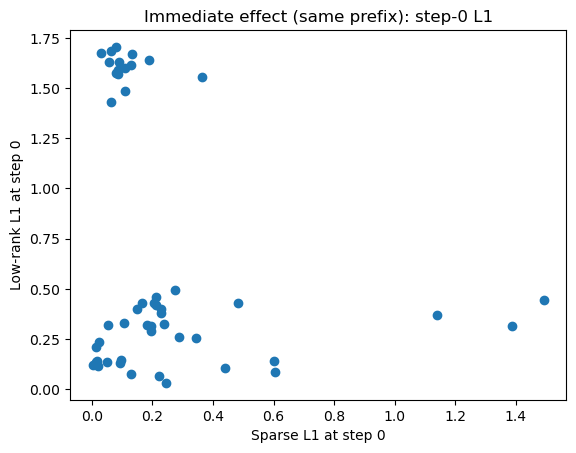

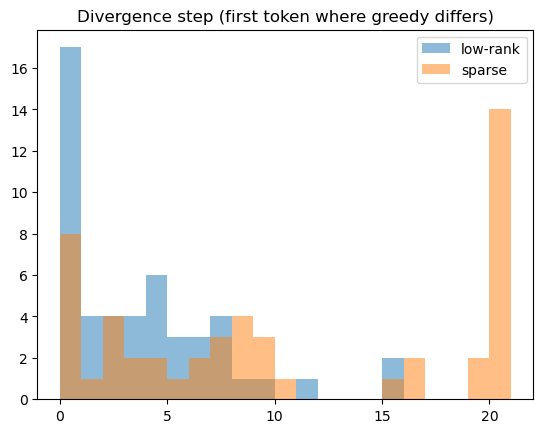

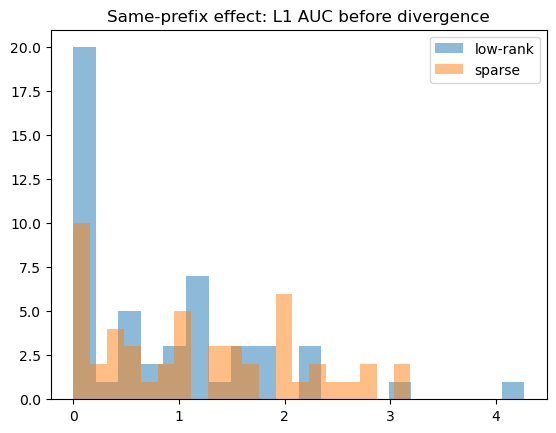

In [12]:
if df is not None:
    # Plots (matplotlib default styling)
    plt.figure()
    plt.scatter(df["sp_l1_step0"], df["lr_l1_step0"])
    plt.xlabel("Sparse L1 at step 0")
    plt.ylabel("Low-rank L1 at step 0")
    plt.title("Immediate effect (same prefix): step-0 L1")
    plt.show()

    plt.figure()
    plt.hist(df["lr_diverge_step"], bins=range(0, K_STEPS+2), alpha=0.5, label="low-rank")
    plt.hist(df["sp_diverge_step"], bins=range(0, K_STEPS+2), alpha=0.5, label="sparse")
    plt.legend()
    plt.title("Divergence step (first token where greedy differs)")
    plt.show()

    plt.figure()
    plt.hist(df["lr_l1_auc_prediv"], bins=20, alpha=0.5, label="low-rank")
    plt.hist(df["sp_l1_auc_prediv"], bins=20, alpha=0.5, label="sparse")
    plt.legend()
    plt.title("Same-prefix effect: L1 AUC before divergence")
    plt.show()


## 6) Generate a small HTML report (top prompts)

This exports an HTML file showing **Baseline vs Low-rank vs Sparse** side-by-side for the most “extreme” prompts.

Tip: `sp_l1_auc_prediv` is often a good criterion for “sparse has a strong effect without instantly diverging.”


In [13]:
from pathlib import Path
from IPython.display import HTML, display

def build_html_report(
    df: pd.DataFrame,
    out_path: Path,
    rank_by: str = "sp_l1_auc_prediv",
    topn: int = 10,
    max_new_tokens: int = 220,
    show_inline: bool = True,
):
    """
    Create an HTML report with side-by-side Baseline / Low-rank / Sparse outputs
    for the top-N prompts by `rank_by`.

    Notes:
      - This re-runs generation for each selected prompt (can take a few minutes).
      - For faster iteration, reduce topn or max_new_tokens.
    """
    assert rank_by in df.columns, f"rank_by={rank_by} not in df columns"

    df_sorted = df.sort_values(rank_by, ascending=False).head(topn)
    prompt_indices = df_sorted["prompt_index"].astype(int).tolist()

    css = """
<style>
.report-wrap { font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial; }
.card { border: 1px solid #ddd; border-radius: 10px; padding: 10px 12px; margin: 14px 0; }
.meta { color: #444; font-size: 13px; margin: 6px 0 10px 0; }
.grid { display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 10px; }
.col { border: 1px solid #eee; border-radius: 10px; padding: 8px 10px; }
.title { font-weight: 650; margin-bottom: 6px; }
pre { margin: 0; white-space: pre-wrap; word-wrap: break-word; font-size: 12.5px; line-height: 1.35; }
details summary { cursor: pointer; font-weight: 600; }
.small { font-size: 12px; color: #555; }
.badge { display: inline-block; padding: 2px 8px; border-radius: 999px; border: 1px solid #ddd; margin-right: 6px; font-size: 12px; }
</style>
"""

    blocks = [
        "<div class='report-wrap'>",
        css,
        f"<h3>Top {topn} prompts by <code>{html.escape(rank_by)}</code></h3>",
        f"<div class='small'>Hyperparams: TOPN_LR={TOPN_LR}, TOPN_SPARSE={TOPN_SPARSE}, ALPHA_LR={ALPHA_LR}, BETA_SPARSE={BETA_SPARSE}, MAX_NEW_TOKENS={max_new_tokens}</div>",
    ]

    for rank, pi in enumerate(tqdm(prompt_indices, desc="Building HTML report"), start=1):
        row = df[df["prompt_index"] == pi].iloc[0].to_dict()
        prompt = prompts[pi]

        itv_lr = make_interventions(pi, L[pi], topn=TOPN_LR, scale=ALPHA_LR)
        itv_sp = make_interventions(pi, S[pi], topn=TOPN_SPARSE, scale=BETA_SPARSE)

        base = run_generate_with_logits(it_model, prompt, interventions=[], max_new_tokens=max_new_tokens, do_sample=False)
        lr   = run_generate_with_logits(it_model, prompt, interventions=itv_lr, max_new_tokens=max_new_tokens, do_sample=False)
        sp   = run_generate_with_logits(it_model, prompt, interventions=itv_sp, max_new_tokens=max_new_tokens, do_sample=False)

        meta_bits = []
        for k in [
            "sparse_score_L1",
            "lr_l1_step0", "sp_l1_step0",
            "lr_diverge_step", "sp_diverge_step",
            "lr_l1_auc_prediv", "sp_l1_auc_prediv",
        ]:
            if k in row:
                try:
                    val = float(row[k])
                    meta_bits.append(f"<span class='badge'>{k}: {val:.3g}</span>")
                except Exception:
                    pass
        meta = " ".join(meta_bits)

        blocks.append(f"""
<div class="card">
  <details open>
    <summary>#{rank} · prompt_index={pi}</summary>
    <div class="meta">{meta}</div>
    <div class="small"><b>Prompt</b></div>
    <pre>{html.escape(prompt)}</pre>
  </details>
  <div style="height:10px"></div>
  <div class="grid">
    <div class="col">
      <div class="title">Baseline</div>
      <pre>{html.escape(base["text"])}</pre>
    </div>
    <div class="col">
      <div class="title">Low-rank (remove L)</div>
      <pre>{html.escape(lr["text"])}</pre>
    </div>
    <div class="col">
      <div class="title">Sparse (remove S)</div>
      <pre>{html.escape(sp["text"])}</pre>
    </div>
  </div>
</div>
""")

    blocks.append("</div>")
    html_str = "\n".join(blocks)
    out_path.write_text(html_str, encoding="utf-8")

    if show_inline:
        display(HTML(html_str))

    return out_path

if df is not None:
    report_path = build_html_report(
        df,
        out_path=Path("report_top10.html"),
        rank_by="sp_l1_auc_prediv",
        topn=10,
        max_new_tokens=MAX_NEW_TOKENS_DEMO,
        show_inline=True,
    )
    print("Wrote:", report_path.resolve())
else:
    print("df is None (RUN_EVAL=False). Skipping report.")


Building HTML report:   0%|          | 0/10 [00:00<?, ?it/s]

Wrote: /home/ubuntu/s3-llm-cache/src/transcoder-anomaly-detection/notebooks/report_top10.html


## 7) Takeaways

**Empirical observations (typical):**
- The low-rank component often captures broad instruction-tuning drift (prompt-general).
- The sparse component is more selective: it matters a lot on some prompts, and little on others.

**Next steps:**
- Use full Robust PCA / PCP (instead of soft-threshold residual)
- Build Δ over **generated tokens**, not only prompt tokens (often increases causal leverage)
- Add an OOD split (prompt-template family → different family) to stress-test robustness
